# Arreglo del PnP — error de traslación antes y después

Comparación A/B contra [originales_paper](../originales_paper/): el binario es el mismo (commit d3fff0e, ventana de
exclusión de 20 s) salvo por el PnP de la verificación geométrica, que ahora usa los intrínsecos rectificados
(las 3 primeras columnas de la matriz de proyección P izquierda) y sin distorsión, en vez de la K cruda + coeficientes de
distorsión.

El PnP no decide si se acepta un loop (solo se rechaza si lanza una excepción), así que los loops detectados deberían ser
exactamente los mismos y la comparación es pareada loop por loop: solo cambia la traslación estimada.

Para cada loop (query `q`, match `m`) el error es $e = |\,\|t_{est}\| - \|p_{gps}(q) - p_{gps}(m)\|\,|$. Se compara solo la
magnitud porque el ground truth no tiene orientación y el detector descarta la rotación de PnP.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '../..')  # evaluation/, donde está commons.py
from commons import load_results, load_ground_truth, translation_errors

RUNS = {  # etiqueta -> carpeta con los .yml de la corrida
    'K cruda (original)': Path('../originales_paper'),
    'K rectificada': Path('.'),
}
PREPARED = Path('/mnt/datalake/datasets/fieldsafe/prepared')
SESSIONS = {  # nombre -> (clave del archivo, sesión de FieldSAFE)
    'Dinámica #1': ('dynamic1', '2016-10-25-11-41-21'),
    'Estática #1': ('static1', '2016-10-25-11-09-42'),
    'Dinámica #2': ('dynamic2', '2016-10-25-12-07-22'),
}
BEFORE, AFTER = RUNS

In [2]:
data = {}  # sesión -> dict con gt y, por corrida, t_est / err
for label, (key, session) in SESSIONS.items():
    runs = {}
    for run, folder in RUNS.items():
        res, q, m, t_est = load_results(folder / f'fs_{key}_results.yml')
        runs[run] = dict(res=res, q=q, m=m, t_est=t_est)
    a, b = runs[BEFORE], runs[AFTER]
    assert a['res']['num_images'] == b['res']['num_images']
    assert np.array_equal(a['q'], b['q']) and np.array_equal(a['m'], b['m']), f'{label}: los loops no coinciden'
    xy = load_ground_truth(PREPARED / f'poses_{session}.csv', num_images=a['res']['num_images'])
    q, m = a['q'], a['m']
    for r in runs.values():
        r['err'], stopped = translation_errors(xy, q, m, r['t_est'])
        r['norm'] = np.linalg.norm(r['t_est'], axis=1)
    data[label] = dict(runs=runs, stopped=stopped, gt=np.linalg.norm(xy[q] - xy[m], axis=1),
                       num_images=a['res']['num_images'])
    print(f"{label}: {a['res']['num_images']} imágenes, {len(q)} loops "
          f"({stopped.sum()} con el robot detenido) — mismos loops en las dos corridas")

Dinámica #1: 11363 imágenes, 197 loops (136 con el robot detenido) — mismos loops en las dos corridas
Estática #1: 9475 imágenes, 198 loops (187 con el robot detenido) — mismos loops en las dos corridas
Dinámica #2: 12182 imágenes, 122 loops (122 con el robot detenido) — mismos loops en las dos corridas


## Error por sesión

`Detenido`: el robot recorrió menos de 1 m entre match y query (se ve a sí mismo después de más de 20 s quieto), así que
la verdad es ‖Δp‖ ≈ 0. `En movimiento`: el resto.

In [3]:
def groups_of(d):
    s = d['stopped']
    return [('Todos', np.ones_like(s)), ('En movimiento', ~s), ('Detenido', s)]

def stats(e):
    return e.mean(), np.median(e), np.percentile(e, 90)

print(f"{'Sesión':<12} {'Grupo':<14} {'n':>4}   {'mediana [m]':>21}   {'media [m]':>21}   {'p90 [m]':>21}")
print(f"{'':<12} {'':<14} {'':>4}   {'antes → después':>21}   {'antes → después':>21}   {'antes → después':>21}")
for label, d in data.items():
    for name, sel in groups_of(d):
        if not sel.any():
            print(f"{label:<12} {name:<14} {0:4d}   {'—':>21}   {'—':>21}   {'—':>21}")
            continue
        ea, eb = d['runs'][BEFORE]['err'][sel], d['runs'][AFTER]['err'][sel]
        (ma, mda, pa), (mb, mdb, pb) = stats(ea), stats(eb)
        print(f"{label:<12} {name:<14} {sel.sum():4d}   {mda:9.3f} → {mdb:9.3f}   {ma:9.3f} → {mb:9.3f}   {pa:9.3f} → {pb:9.3f}")

Sesión       Grupo             n             mediana [m]               media [m]                 p90 [m]
                                         antes → después         antes → después         antes → después
Dinámica #1  Todos           197       0.149 →     0.003       0.143 →     0.028       0.164 →     0.093
Dinámica #1  En movimiento    61       0.092 →     0.051       0.127 →     0.084       0.252 →     0.205
Dinámica #1  Detenido        136       0.151 →     0.002       0.150 →     0.003       0.162 →     0.007
Estática #1  Todos           198       0.149 →     0.004       0.214 →     0.084       0.163 →     0.020
Estática #1  En movimiento    11       0.163 →     0.033       0.524 →     0.713       0.311 →     0.174
Estática #1  Detenido        187       0.149 →     0.004       0.196 →     0.047       0.161 →     0.012
Dinámica #2  Todos           122       0.155 →     0.004       0.154 →     0.005       0.163 →     0.011
Dinámica #2  En movimiento     0                       

## Distribución del error

Cada panel es una sesión; para cada grupo, la caja de la izquierda es la K cruda y la de la derecha la K rectificada.
Los puntos son los loops; ▲ marca los que quedan fuera de escala.

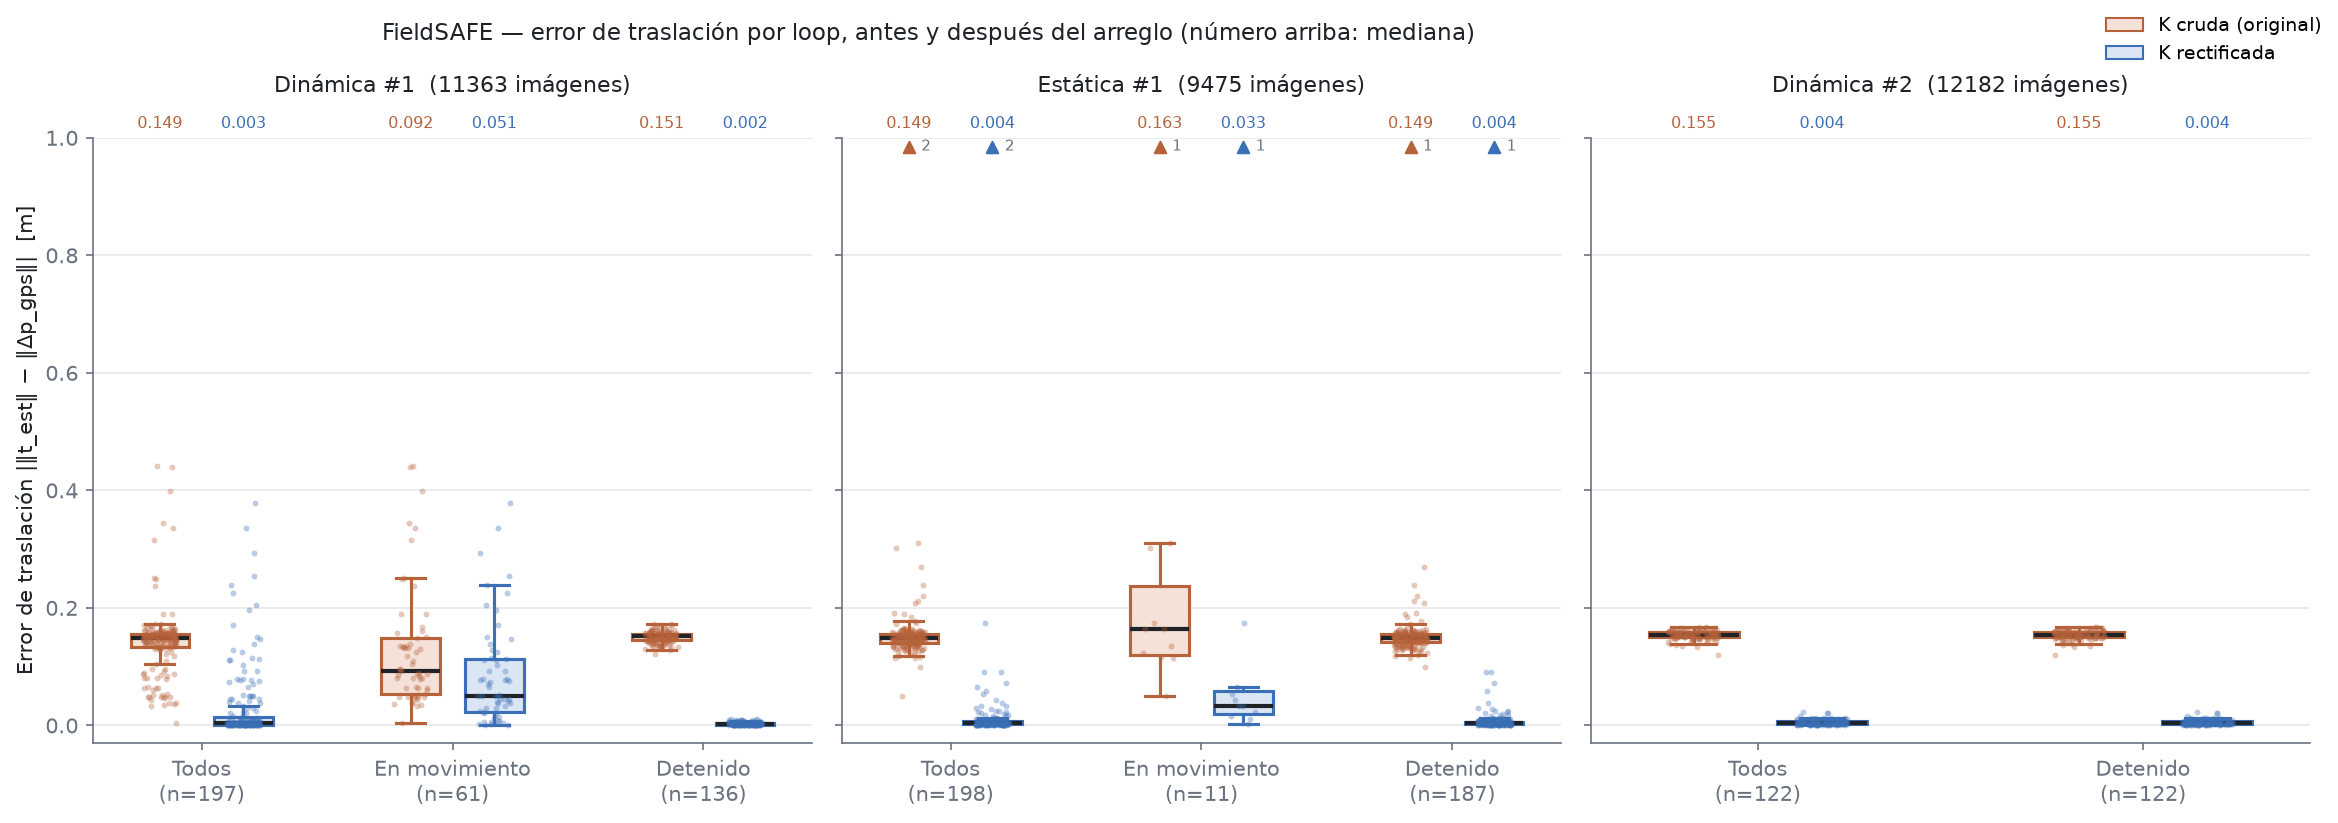

In [4]:
COLORS = {BEFORE: '#b6623b', AFTER: '#3b6fb6'}
FILL = {BEFORE: '#f5e1d8', AFTER: '#dbe6f5'}
ink, muted = '#1f2328', '#6b7280'
Y_MAX = 1.0  # m
rng = np.random.default_rng(0)

def style(ax):
    ax.grid(axis='y', color='#e5e7eb', linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(muted)
    ax.tick_params(colors=muted)

fig, axes = plt.subplots(1, len(data), figsize=(5.2 * len(data), 5.5), dpi=150, sharey=True)
for ax, (label, d) in zip(axes, data.items()):
    groups = [(n, sel) for n, sel in groups_of(d) if sel.any()]
    for gi, (name, sel) in enumerate(groups):
        for ri, run in enumerate(RUNS):
            e = d['runs'][run]['err'][sel]
            x = gi * 3 + 1 + ri
            ax.boxplot([e], positions=[x], widths=0.7, showfliers=False, patch_artist=True,
                       boxprops=dict(facecolor=FILL[run], edgecolor=COLORS[run], linewidth=1.5),
                       medianprops=dict(color=ink, linewidth=2),
                       whiskerprops=dict(color=COLORS[run], linewidth=1.5),
                       capprops=dict(color=COLORS[run], linewidth=1.5))
            inside = e <= Y_MAX
            jitter = x + rng.uniform(-0.2, 0.2, len(e))
            ax.scatter(jitter[inside], e[inside], s=8, color=COLORS[run], alpha=0.35, linewidths=0, zorder=3)
            if (~inside).any():
                ax.scatter([x], [Y_MAX * 0.985], marker='^', s=30, color=COLORS[run], zorder=3, clip_on=False)
                ax.annotate(f"{(~inside).sum()}", (x + 0.15, Y_MAX * 0.985), fontsize=7, color=muted, va='center')
            ax.annotate(f"{np.median(e):.3f}", (x, 1.01), xycoords=('data', 'axes fraction'), ha='center',
                        va='bottom', fontsize=7.5, color=COLORS[run], annotation_clip=False)
    ax.set_xticks([gi * 3 + 1.5 for gi in range(len(groups))], [f"{n}\n(n={sel.sum()})" for n, sel in groups])
    ax.set_xlim(0.2, len(groups) * 3 - 0.2)
    ax.set_ylim(-0.03, Y_MAX)
    ax.set_title(f"{label}  ({d['num_images']} imágenes)", fontsize=10.5, color=ink, pad=22)
    style(ax)
axes[0].set_ylabel('Error de traslación |‖t_est‖ − ‖Δp_gps‖|  [m]', color=ink)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=FILL[r], edgecolor=COLORS[r]) for r in RUNS]
fig.legend(handles, list(RUNS), loc='upper right', frameon=False, fontsize=9)
fig.suptitle('FieldSAFE — error de traslación por loop, antes y después del arreglo (número arriba: mediana)',
             fontsize=11, color=ink, x=0.4)
fig.tight_layout()
fig.savefig('translation_error_boxplot.png', bbox_inches='tight')

## Traslación estimada contra la verdad

Cada punto es un loop: en x la distancia GPS entre query y match, en y la ‖t‖ que devuelve PnP. Sobre la diagonal la
estimación es perfecta. Los loops con el robot detenido quedan en x ≈ 0.

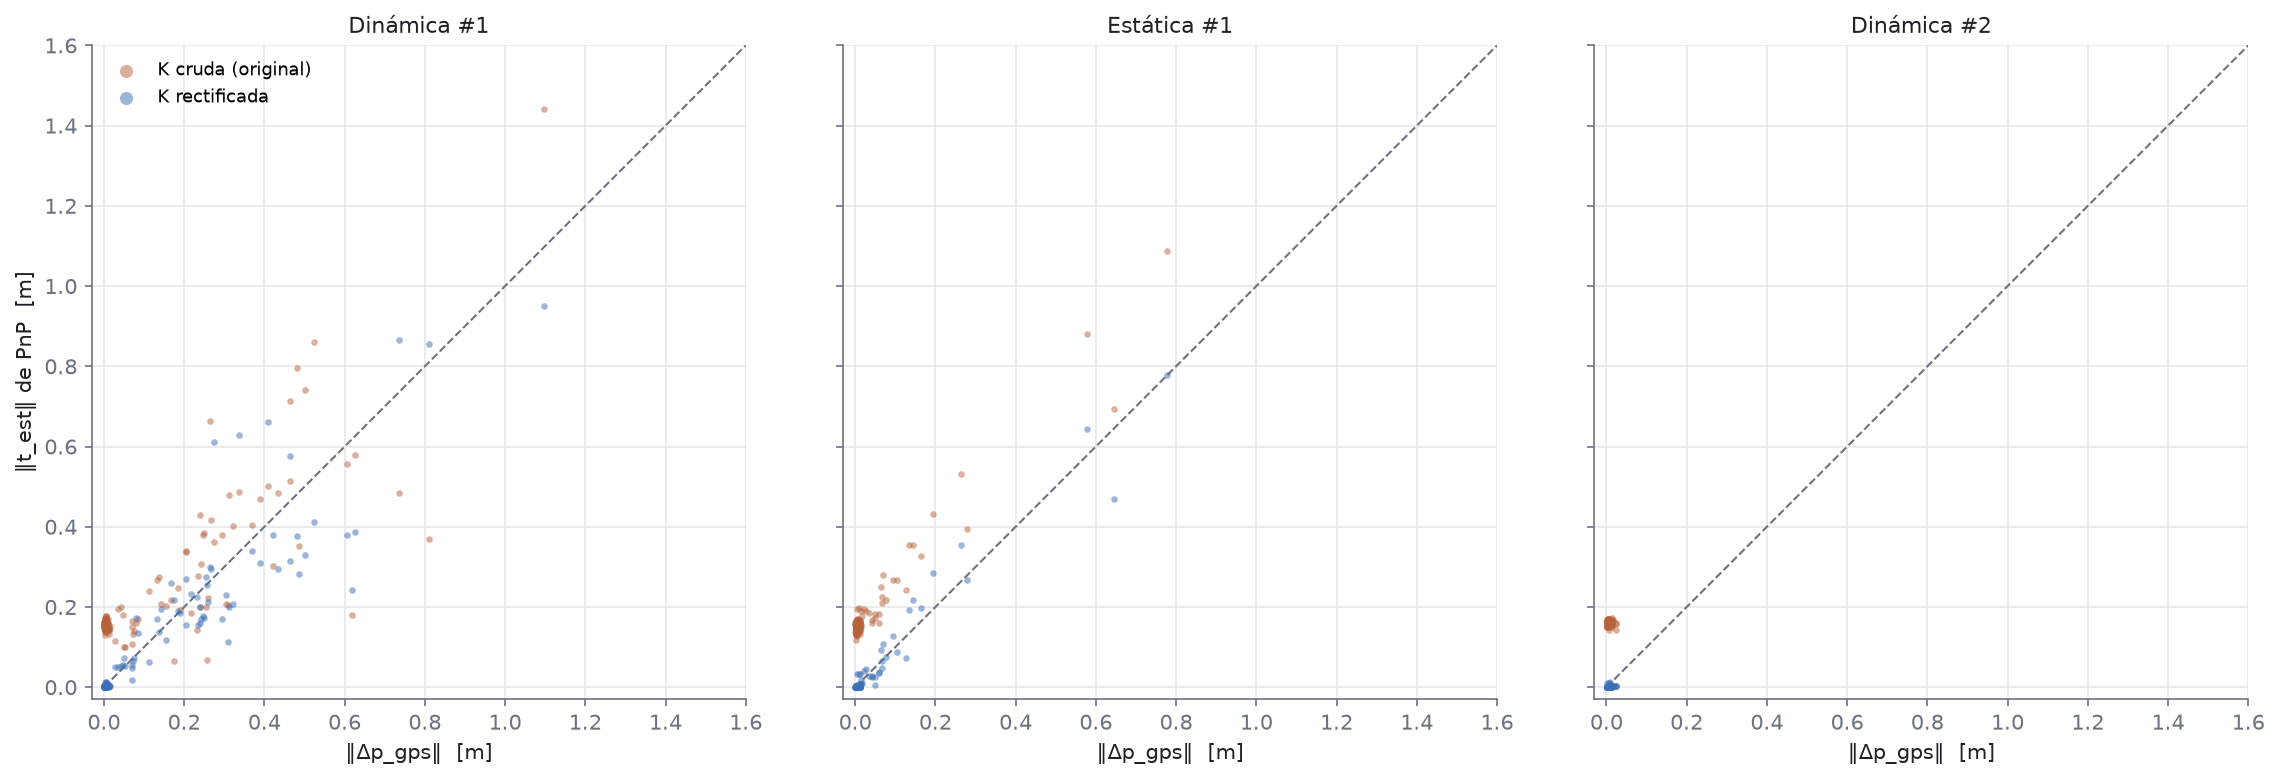

In [5]:
fig, axes = plt.subplots(1, len(data), figsize=(5.2 * len(data), 5), dpi=150, sharex=True, sharey=True)
LIM = 1.6
for ax, (label, d) in zip(axes, data.items()):
    ax.plot([0, LIM], [0, LIM], color=muted, linewidth=1, linestyle='--', zorder=1)
    for run in RUNS:
        r = d['runs'][run]
        ax.scatter(d['gt'], r['norm'], s=10, color=COLORS[run], alpha=0.5, linewidths=0, label=run, zorder=2)
    ax.set_xlim(-0.03, LIM)
    ax.set_ylim(-0.03, LIM)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=10.5, color=ink)
    ax.set_xlabel('‖Δp_gps‖  [m]', color=ink)
    style(ax)
    ax.grid(axis='x', color='#e5e7eb', linewidth=0.8)
axes[0].set_ylabel('‖t_est‖ de PnP  [m]', color=ink)
axes[0].legend(frameon=False, fontsize=8.5, markerscale=2)
fig.tight_layout()
fig.savefig('translation_scatter.png', bbox_inches='tight')

## Loops con el robot detenido

Con la verdad en ≈ 0, ‖t_est‖ mide directamente el sesgo del PnP.

In [6]:
for label, d in data.items():
    s = d['stopped']
    if not s.any():
        continue
    na, nb_ = d['runs'][BEFORE]['norm'][s], d['runs'][AFTER]['norm'][s]
    print(f"{label:<12} n={s.sum():3d}   ‖t_est‖ mediana {np.median(na) * 1000:6.1f} mm → {np.median(nb_) * 1000:5.1f} mm"
          f"   (p90 {np.percentile(na, 90) * 1000:6.1f} → {np.percentile(nb_, 90) * 1000:5.1f} mm)"
          f"   ‖Δp_gps‖ mediana {np.median(d['gt'][s]) * 1000:5.1f} mm")

Dinámica #1  n=136   ‖t_est‖ mediana  155.5 mm →   2.6 mm   (p90  165.2 →   4.7 mm)   ‖Δp_gps‖ mediana   4.3 mm
Estática #1  n=187   ‖t_est‖ mediana  155.6 mm →   1.1 mm   (p90  169.9 →  24.6 mm)   ‖Δp_gps‖ mediana   5.0 mm
Dinámica #2  n=122   ‖t_est‖ mediana  160.3 mm →   0.9 mm   (p90  167.3 →   2.2 mm)   ‖Δp_gps‖ mediana   4.7 mm


## Conclusiones

- **Robot detenido** (445 de 517 loops): el sesgo desaparece. ‖t_est‖ baja de ~155 mm a 1–3 mm de mediana, del orden de
  la distancia GPS entre query y match (~5 mm, que incluye el ruido del GPS). Era el sesgo de usar la K cruda (fx 556) con
  puntos triangulados con la rectificada (fx 581).
- **En movimiento**: la mediana del error baja de 0,092 a 0,051 m en Dinámica #1 (61 loops) y de 0,163 a 0,033 m en
  Estática #1 (11 loops). En el gráfico de dispersión, la nube de la K cruda queda por encima de la diagonal (sobreestima
  ‖t‖) y la de la K rectificada queda alrededor de ella.
- **La media de Estática #1 sube** (0,52 → 0,71 m en movimiento) por un solo loop: q=618 / m=246, donde PnP ya fallaba con la K
  cruda (‖t‖ = 4,2 m para 0,12 m reales) y con la rectificada da 7,5 m. Lo mismo pasa con q=541 / m=293 (detenido, ~8 m
  de ‖t‖ con las dos K). Son fallas de PnP con malas correspondencias, no del arreglo: el detector no valida la traslación,
  así que esos loops pasan igual.